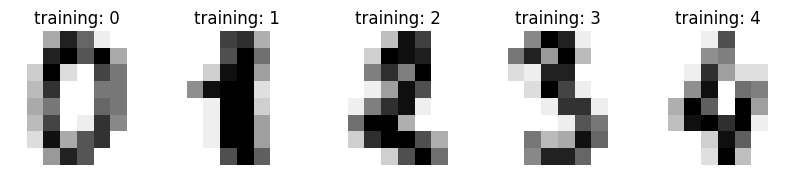

In [9]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()

fig, axes = plt.subplots(1, 5, figsize=(10, 3), dpi= 100)

for ax, img, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(img, cmap=plt.cm.grey_r, interpolation="nearest")
    ax.set_title(f"training: {label}")

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler
import numpy as np

digits_X, digits_y = load_digits(return_X_y= True)

train_X, test_X, train_y, test_y = train_test_split(digits_X, digits_y, test_size=.5, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
log = LogisticRegression(max_iter=10000)

#scaler = MinMaxScaler()

scaled_train_X = train_X #scaler.fit_transform(train_X)
scaled_test_X = test_X #scaler.transform(test_X)

knn.fit(scaled_train_X, train_y)
log.fit(scaled_train_X, train_y)

Y_knn = knn.predict(test_X)
Y_log = log.predict(test_X)

print(classification_report(test_y, Y_knn))
print(classification_report(test_y, Y_log))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       0.99      1.00      0.99        89
           2       0.99      1.00      0.99        83
           3       0.99      0.96      0.97        93
           4       0.99      1.00      0.99        93
           5       0.99      0.98      0.98        99
           6       1.00      1.00      1.00        98
           7       0.97      1.00      0.98        87
           8       0.98      0.98      0.98        83
           9       0.98      0.96      0.97        92

    accuracy                           0.99       899
   macro avg       0.99      0.99      0.99       899
weighted avg       0.99      0.99      0.99       899

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        82
           1       0.95      0.93      0.94        89
           2       0.94      1.00      0.97        83
           3       0.99 

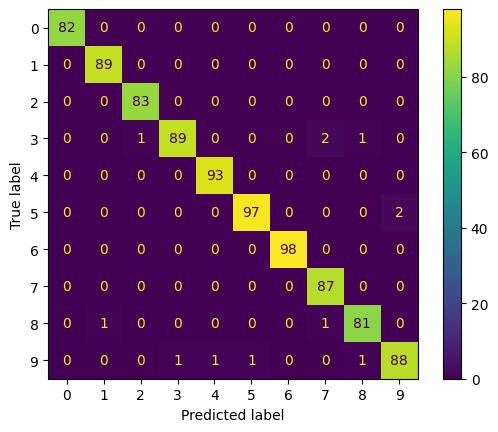

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_y, Y_knn)
ConfusionMatrixDisplay(cm).plot()

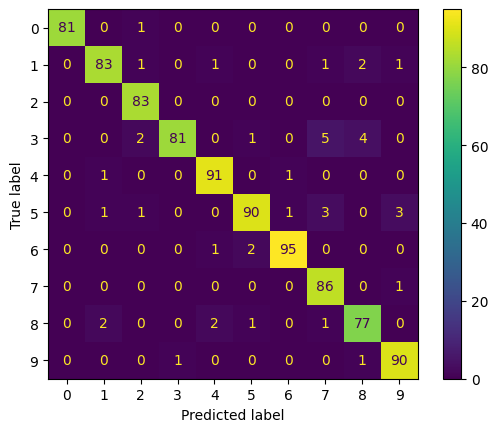

In [16]:
cm = confusion_matrix(test_y, Y_log)
ConfusionMatrixDisplay(cm).plot()

[Text(0.5, 1.0, 'Elbow'), Text(0.5, 0, 'k'), Text(0, 0.5, 'Error')]

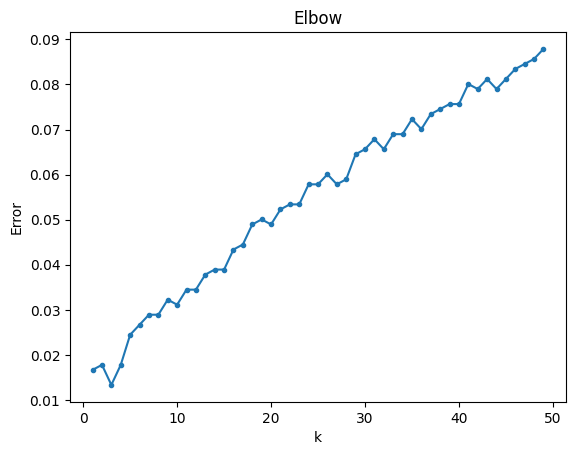

In [19]:
from sklearn.metrics import accuracy_score

error = 1 - accuracy_score(test_y, Y_knn)
error_list = []

for k in range(1, 50):
    model_knn = KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(scaled_train_X, train_y)
    Y_pred = model_knn.predict(scaled_test_X)

    error_list += [(1 - accuracy_score(test_y, Y_pred))]

fig, ax = plt.figure(), plt.axes()

ax.plot(range(1, len(error_list) + 1), error_list, ".-")
ax.set(title="Elbow", xlabel="k", ylabel="Error")


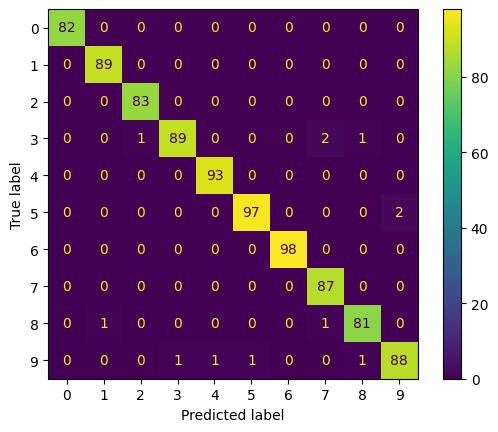

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

model = KNeighborsClassifier(n_neighbors=3)

model.fit(scaled_train_X, train_y)

pred = model.predict(scaled_test_X)

ConfusionMatrixDisplay.from_predictions(test_y, pred)